In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame
df = housing.frame

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Check basic information
print("\nDataset information:")
df.info()

Dataset shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate Rows:
0


In [8]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# Simple Linear Regression
# Using MedInc to predict MedHouseVal

X = df[['MedInc']]
y = df['MedHouseVal']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 1)
Target shape: (20640,)


In [10]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


In [11]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318 2.42165249
 2.57647226 1.99229181 2.45893168 3.84677436]


In [13]:
# Evaluate the Simple Linear Regression model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Simple Linear Regression Results")
print("--------------------------------")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R²  : {r2:.4f}")

Simple Linear Regression Results
--------------------------------
MAE : 0.6299
MSE : 0.7091
R²  : 0.4589


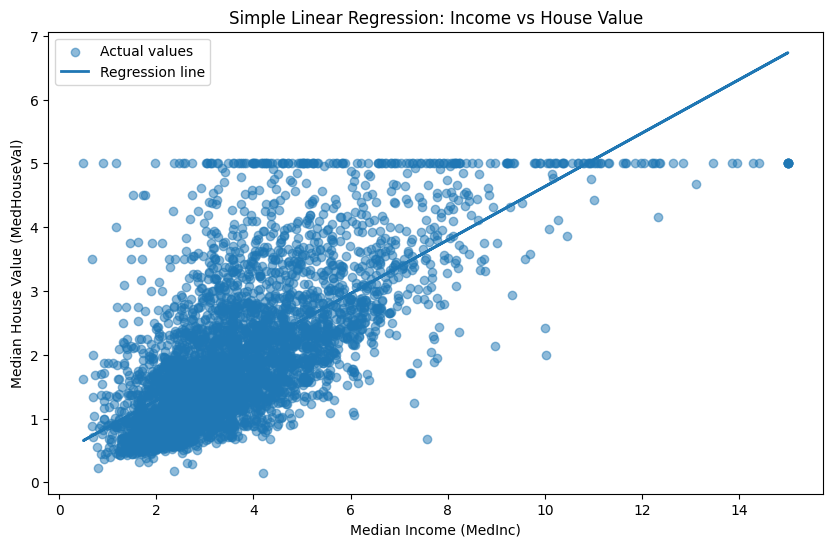

In [14]:
# Plot the Simple Linear Regression line

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test['MedInc'],
    y_test,
    alpha=0.5,
    label='Actual values'
)

plt.plot(
    X_test['MedInc'],
    y_pred,
    linewidth=2,
    label='Regression line'
)

plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()

plt.show()

In [15]:
# Display model coefficients

print("Intercept:", model.intercept_)
print("Coefficient for MedInc:", model.coef_[0])

Intercept: 0.4445972916907879
Coefficient for MedInc: 0.4193384939381271


In [16]:
# Multiple Linear Regression

features = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup'
]

X = df[features]
y = df['MedHouseVal']

print("Features used:")
print(features)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features used:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

Feature shape: (20640, 6)
Target shape: (20640,)


In [17]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


In [18]:
# Train Multiple Linear Regression model

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [19]:
# Make predictions

y_pred_multiple = multiple_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_multiple[:10])

First 10 predictions:
[1.00100537 1.56005635 2.67713262 2.64763331 1.98229968 2.17781246
 2.65796237 2.16502864 2.43063443 4.23099178]


In [20]:
# Evaluate the Multiple Linear Regression model

mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression Results")
print("----------------------------------")
print(f"MAE : {mae_multiple:.4f}")
print(f"MSE : {mse_multiple:.4f}")
print(f"R²  : {r2_multiple:.4f}")

Multiple Linear Regression Results
----------------------------------
MAE : 0.5792
MSE : 0.6422
R²  : 0.5099


In [21]:
# Compare Simple vs Multiple Linear Regression

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        mae,
        mae_multiple
    ],
    'MSE': [
        mse,
        mse_multiple
    ],
    'R²': [
        r2,
        r2_multiple
    ]
})

comparison

,Model,MAE,MSE,R²
0,Simple Linear Regression,0.629909,0.709116,0.458859
1,Multiple Linear Regression,0.579214,0.642187,0.509934


In [22]:
# Display coefficients of the Multiple Linear Regression model

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.546161
1,HouseAge,0.016788
2,AveRooms,-0.223920
3,AveBedrms,1.115493
4,Population,0.000023
5,AveOccup,-0.004618


In [23]:
# Display the intercept

print("Intercept:", multiple_model.intercept_)

Intercept: -0.5528727644615126


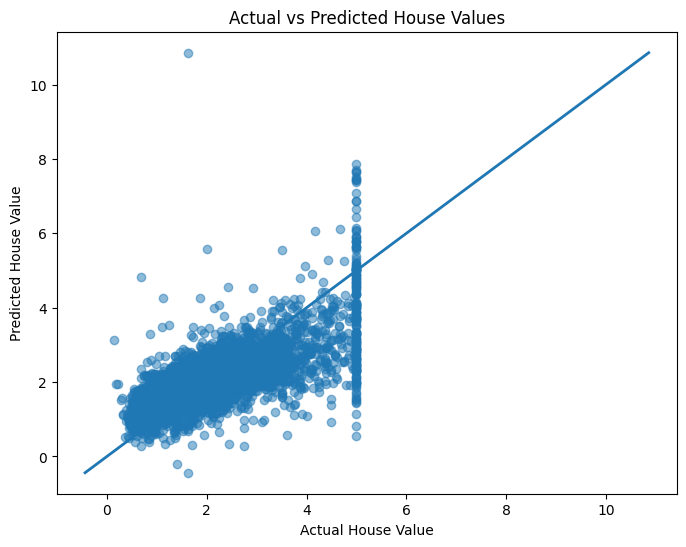

In [24]:
# Actual vs Predicted House Values

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_multiple,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_multiple.min())
max_value = max(y_test.max(), y_pred_multiple.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()